# Mobile Application Download Trends & Category Growth Analysis

**Business Context**:

Zoom Ads, an advertising agency, aims to optimize its ad placement strategy by understanding trends within the Google Play Store ecosystem. With Android holding a dominant global market share, identifying high-performing app categories is critical for maximizing advertising ROI.

**Objectives**:

- Analyze Google Play Store data to identify trends in app downloads, ratings, and categories
- Identify high-growth and high-engagement app categories
- Assess factors driving user engagement and app popularity
- Generate insights to support targeted advertising strategies and optimize campaign ROI


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.5f' % x) # To supress numerical display in scientific notations

## Sanity Checks

#### Loading and displaying the first and last few rows of the dataset

In [3]:
df = pd.read_csv("C:/Users/HP PC/Downloads/Play_Store_2.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice
0,War Dragons,Others,3.90000,160604.00000,270.00000,10000000.00000,Free,0.00000,Everyone,Yes,Yes,Yes
1,CV-Library Job Search,BUSINESS,4.40000,NaN,46.00000,100000.00000,Free,0.00000,Everyone,No,No,No
2,Surah Al-Waqiah,BOOKS_AND_REFERENCE,NaN,1201.00000,29.00000,100000.00000,Free,0.00000,Everyone,Yes,No,No
3,Ay,Others,NaN,11.00000,36.00000,5000.00000,Free,0.00000,Teen,Yes,No,No
4,EA Plus,Others,2.50000,12.00000,12.00000,1000.00000,Free,0.00000,Everyone,No,No,No


In [3]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice
4148,Home Pony 2,FAMILY,4.00000,20977.00000,26.00000,1000000.00000,Free,0.00000,Everyone,Yes,No,No
4149,Realtor.com Real Estate: Homes for Sale and Rent,Others,4.50000,162243.00000,12.00000,10000000.00000,Free,0.00000,Everyone,Yes,No,No
4150,Uber Eats: Food Delivery,Others,4.30000,312204.00000,270.00000,19970000.00000,Free,0.00000,Everyone,Yes,No,Yes
4151,Faraway 4: Ancient Escape,Others,4.30000,12207.00000,270.00000,1000000.00000,Free,0.00000,Everyone,Yes,Yes,Yes
4152,Jump'N'Shoot Attack,GAME,4.10000,155.00000,32.00000,1000.00000,Paid,2.49000,Everyone,No,No,No


- There appears to be some missing data in the *Rating* and *Review* columns, would need to be investigated further
- Every other thing appears okay

#### Checking the shape of the dataset

In [4]:
df.shape

(4153, 12)

There are 4153 rows and and 12 columns in the dataset

#### Checking the datatypes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4153 entries, 0 to 4152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               4153 non-null   object 
 1   Category          4153 non-null   object 
 2   Rating            3976 non-null   float64
 3   Reviews           4029 non-null   float64
 4   Size              4153 non-null   float64
 5   Installs          4153 non-null   float64
 6   Paid/Free         4153 non-null   object 
 7   Price             4153 non-null   float64
 8   Content Rating    4153 non-null   object 
 9   Ad Supported      4153 non-null   object 
 10  In App Purchases  4153 non-null   object 
 11  Editors Choice    4153 non-null   object 
dtypes: float64(5), object(7)
memory usage: 389.5+ KB


- There are 5 numerical and 7 categorical features in the dataset
- We will convert the *Reviews* & *Installs* datatype to integer as they contain discrete data

In [9]:
#df['Reviews'] = df['Reviews'].astype('int64') #the Reviews column can not be converted until its missing values are treated
df['Installs'] = df['Installs'].astype('int64')

In [7]:
df.dtypes

App                  object
Category             object
Rating              float64
Reviews             float64
Size                float64
Installs              int64
Paid/Free            object
Price               float64
Content Rating       object
Ad Supported         object
In App Purchases     object
Editors Choice       object
dtype: object

The datatype conversion was successful. However, *Reviews* has some null values present and hence, we can not convert its datatype until those missing values are treated

#### Checking the statistical summary

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,3976.00000,4.18949,0.51979,1.00000,4.00000,4.30000,4.50000,5.00000
Reviews,4029.00000,66964.20675,107418.85154,1.00000,224.00000,7461.00000,78219.00000,312204.00000
Size,4153.00000,82.25441,92.25633,0.01100,22.00000,42.00000,84.00000,270.00000
Installs,4153.00000,3232705.64195,5421343.28486,1.00000,10000.00000,500000.00000,5000000.00000,19970000.00000
Price,4153.00000,0.56534,8.92631,0.00000,0.00000,0.00000,0.00000,399.99000


- 50% of apps have ratings above 4.3
- Asides *Rating* whose median is slightly greater than the mean, all other columns have means greater than median which means they are positively skewed
- *Reviews* and *Installs* have large standard deviations which indicate that there are likely extreme values present
- 75% of apps have 0 price meaning they are free

#### Checking for missing values

In [9]:
df.isnull().sum()

App                   0
Category              0
Rating              177
Reviews             124
Size                  0
Installs              0
Paid/Free             0
Price                 0
Content Rating        0
Ad Supported          0
In App Purchases      0
Editors Choice        0
dtype: int64

As observed earlier, *Rating* and *Reviews* have 177 and 124 missing data respectively. This would be treated momentarily


#### Checking for duplicates in the dataset

In [96]:
df.duplicated().sum()

0

There are no duplicate rows in the dataset

#### Checking the categorical levels in the dataset

In [11]:
cat_cols = ['App','Category','Paid/Free','Content Rating','Ad Supported','In App Purchases','Editors Choice']

In [13]:
for col in cat_cols:
    print(col, '\n')
    print(df[col].value_counts())
    print('-' * 45)
    print(df[col].value_counts(normalize=True), '\n')

App 

War Dragons                                           1
Random Dice: PvP Defense                              1
Scout GPS Navigation & Meet Up                        1
Marble - Temple Quest                                 1
QuickBooks Self-Employed:Mileage Tracker and Taxes    1
                                                     ..
KING`s RAID                                           1
BU Syllabus                                           1
Read Unlimitedly! Kids'n Books                        1
Grand Theft Auto V: The Manual                        1
Jump'N'Shoot Attack                                   1
Name: App, Length: 4153, dtype: int64
---------------------------------------------
War Dragons                                          0.00024
Random Dice: PvP Defense                             0.00024
Scout GPS Navigation & Meet Up                       0.00024
Marble - Temple Quest                                0.00024
QuickBooks Self-Employed:Mileage Tracker and Taxes

In [14]:
df['App'].nunique()

4153

In [15]:
df['Category'].nunique()

15

In [16]:
df['Content Rating'].nunique()

4

There are 4153 apps, 15 app categories and 4 age groups targeted by apps

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4153 entries, 0 to 4152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               4153 non-null   object 
 1   Category          4153 non-null   object 
 2   Rating            3976 non-null   float64
 3   Reviews           4029 non-null   float64
 4   Size              4153 non-null   float64
 5   Installs          4153 non-null   int64  
 6   Paid/Free         4153 non-null   object 
 7   Price             4153 non-null   float64
 8   Content Rating    4153 non-null   object 
 9   Ad Supported      4153 non-null   object 
 10  In App Purchases  4153 non-null   object 
 11  Editors Choice    4153 non-null   object 
dtypes: float64(4), int64(1), object(7)
memory usage: 389.5+ KB


## Univariate Analysis

#### Let's start with the numerical features

#### Observations on Rating

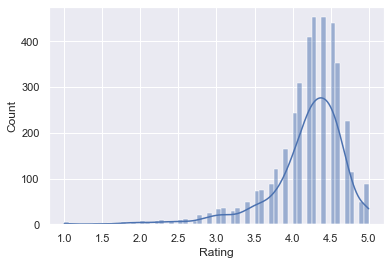

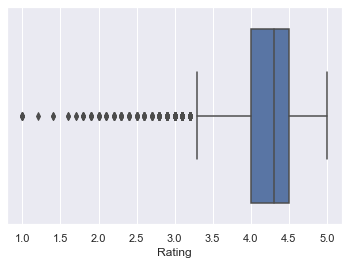

In [18]:
sns.histplot(df, x='Rating', kde=True)
plt.show()
sns.boxplot(data=df, x='Rating')
plt.show()

- Rating distirbution is left skewed
- Majority of the apps are rated above 3.5
- Ratings below 3.4 are considered outliers

#### Observations on Reviews

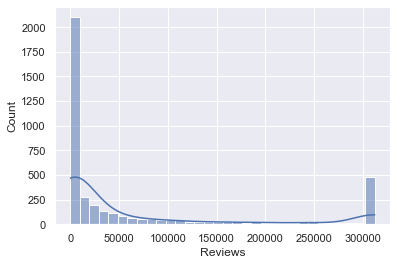

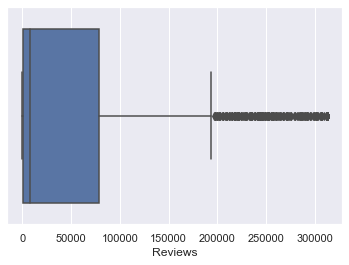

In [19]:
sns.histplot(df, x='Reviews', kde=True)
plt.show()
sns.boxplot(data=df, x='Reviews')
plt.show()

- The distribution is heavily right skewed
- 50% of reviews are below 15000
- Reviews above about 190000 constitute outliers, and they are many

#### Observations on Size

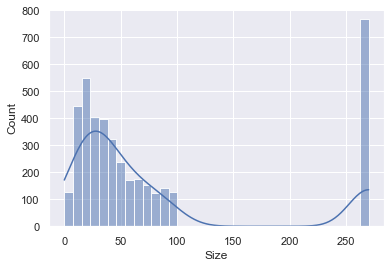

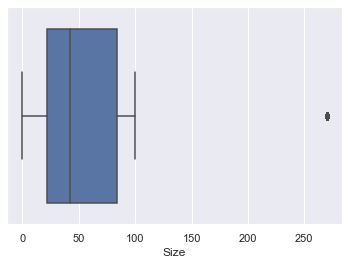

In [20]:
sns.histplot(df, x='Size', kde=True)
plt.show()
sns.boxplot(data=df, x='Size')
plt.show()

- The ditribution is right skewed
- There is a concentration of outliers above 260, let's investigate further

In [21]:
df.loc[df['Size']>200]['Size'].value_counts()

270.00000    767
Name: Size, dtype: int64

In [22]:
df.loc[df['Size']<101]['Size'].count()

3386

All the outliers have size 270kb, and they are 767 in number

#### Observations on Installs

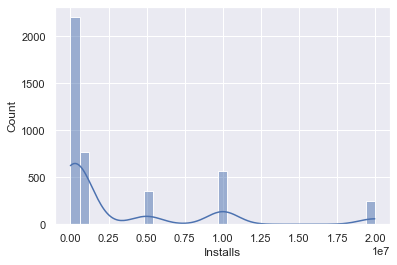

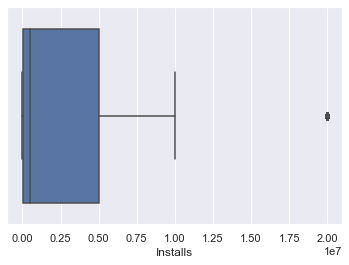

In [23]:
sns.histplot(df, x='Installs', kde=True)
plt.show()
sns.boxplot(data=df, x='Installs')
plt.show()

- The distribution of Installs is positively skewed
- There is concentration of outliers at about 20000000

In [24]:
df.loc[df['Installs']>19000000]['Installs'].value_counts()

19970000    247
Name: Installs, dtype: int64

There are 247 outliers and each of them constitutes 19970000 installs

#### Observations on Price

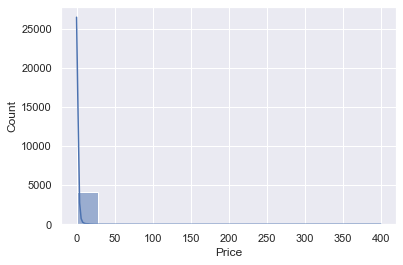

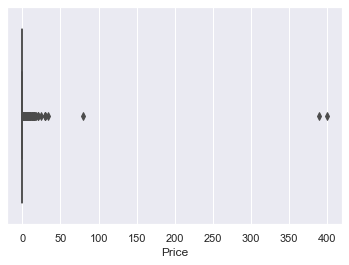

In [25]:
sns.histplot(df, x='Price', kde=True)
plt.show()
sns.boxplot(data=df, x='Price')
plt.show()

- Extremely right skewed distribution
- All values above 0 are outliers

In [26]:
df.loc[df['Price']>0]['Price'].count()

325

All 325 apps that are not free have their prices as outliers

#### Moving to the categorical features

#### Observations on Category

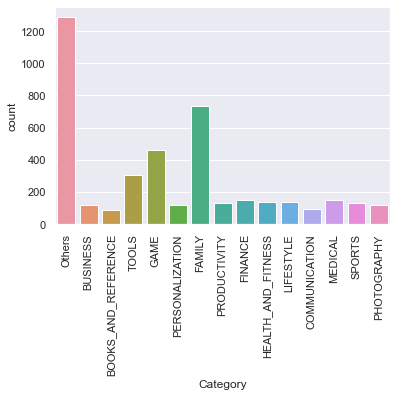

In [27]:
sns.countplot(data=df, x='Category')
plt.xticks(rotation=90)
plt.show()

- Most apps fall under category *Others*, followed by *Family* then *Games*
- *Books and References* & *Communication* have the least apps

#### Observations on Content Rating

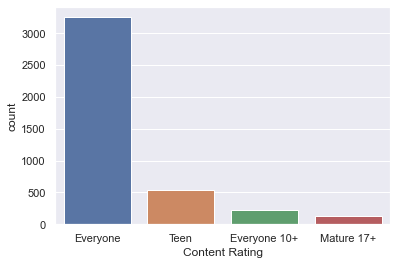

In [28]:
sns.countplot(data=df, x='Content Rating')
plt.show()

- Majority of the apps are targeted at *Everyone*
- *Mature 17+* has the lowest number of apps

#### Observations on Paid/Free

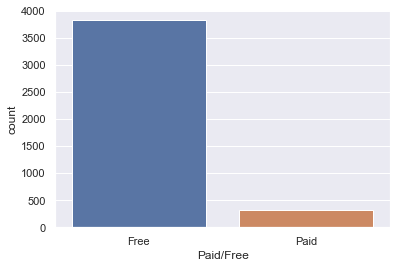

In [29]:
sns.countplot(data=df, x='Paid/Free')
plt.show()

In [30]:
df['Paid/Free'].value_counts()

Free    3828
Paid     325
Name: Paid/Free, dtype: int64

The greater number of apps in the dataset are free, at 3828 apps compared to just 325 paid apps

In [31]:
(df.loc[(df['Paid/Free']=='Paid') & (df['Price']<10) ])

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice
7,EM Launcher Pro,PERSONALIZATION,4.20000,35.00000,0.02400,1000,Paid,3.99000,Everyone,No,No,No
45,Hitman Sniper,GAME,4.60000,312204.00000,29.00000,10000000,Paid,0.99000,Mature 17+,Yes,Yes,Yes
61,PORTABLE SOCCER DX,SPORTS,4.40000,552.00000,16.00000,5000,Paid,1.00000,Everyone,No,No,No
67,Iron Marines: RTS Offline Real Time Strategy Game,Others,4.70000,58260.00000,270.00000,500000,Paid,2.99000,Everyone 10+,No,Yes,Yes
109,Portable Wi-Fi hotspot Premium,COMMUNICATION,3.70000,481.00000,0.42000,10000,Paid,0.99000,Everyone,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...
4100,Jetting for Honda CR dirt bike,SPORTS,4.10000,7.00000,34.00000,100,Paid,3.49000,Everyone,No,No,No
4118,Call of Duty:Black Ops Zombies,GAME,4.20000,13004.00000,46.00000,100000,Paid,6.99000,Teen,No,Yes,No
4129,Guns'n'Glory Zombies Premium,FAMILY,4.10000,313.00000,34.00000,5000,Paid,2.99000,Everyone 10+,Yes,Yes,No
4140,Five Nights at Freddy's,GAME,4.60000,100805.00000,50.00000,1000000,Paid,2.99000,Teen,No,Yes,No


In [32]:
(df.loc[df['Paid/Free']=='Paid'])['Price'].value_counts()

2.99000      63
4.99000      47
0.99000      47
3.99000      35
1.99000      26
1.49000      14
5.99000      10
9.99000       9
6.99000       8
2.49000       6
14.99000      6
7.99000       5
4.49000       5
3.49000       4
29.99000      3
10.00000      2
12.99000      2
19.99000      2
2.00000       2
7.49000       2
10.99000      1
8.49000       1
13.99000      1
17.99000      1
1.29000       1
24.99000      1
399.99000     1
3.08000       1
1.76000       1
33.99000      1
5.49000       1
8.99000       1
79.99000      1
4.29000       1
14.00000      1
15.99000      1
3.28000       1
15.46000      1
1.59000       1
1.97000       1
2.90000       1
4.77000       1
4.84000       1
389.99000     1
1.20000       1
1.00000       1
11.99000      1
Name: Price, dtype: int64

#### Observations on Ad Supported

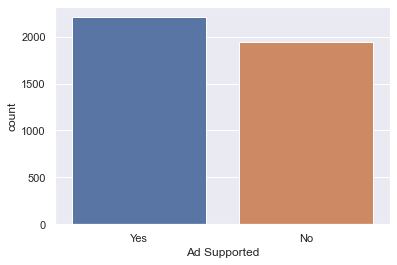

In [33]:
sns.countplot(data=df, x='Ad Supported')
plt.show()

In [34]:
df['Ad Supported'].value_counts(normalize=True)

Yes   0.53166
No    0.46834
Name: Ad Supported, dtype: float64

There is just slightly more Ad Supported apps than apps that do not support Ads, 53% to approximately 47%

#### Observations on In App Purchases

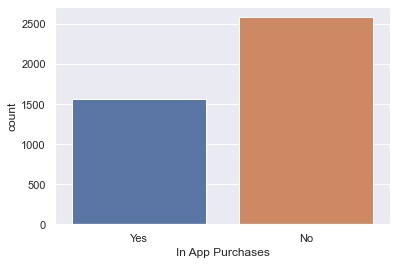

In [35]:
sns.countplot(data=df, x='In App Purchases')
plt.show()

In [36]:
df['In App Purchases'].value_counts()

No     2586
Yes    1567
Name: In App Purchases, dtype: int64

Apps with no in app purchases are higher than those without, 2586 apps to 1567 apps

#### Observations on Editors Choice

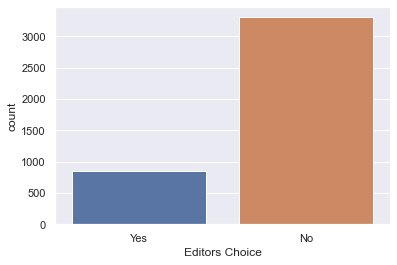

In [38]:
sns.countplot(data=df, x='Editors Choice')
plt.show()

Out of 4153 apps, more than 3000 are not rated as editor's choice

## Bivariate Analysis

#### Correlation by Heatmap

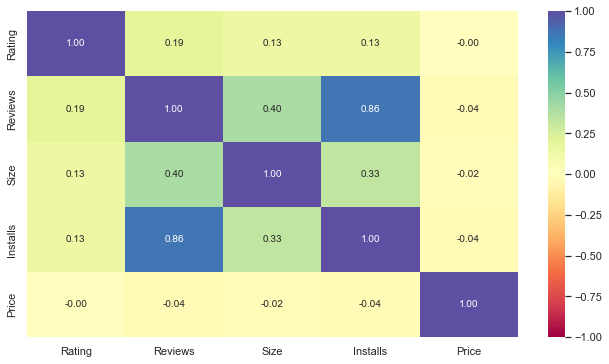

In [39]:
plt.figure(figsize=(11,6))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral');

- *Reviews* has a strong positve relationship with *Installs*, this indicates that most of the users who install apps also leave a review
- *Size* also has a significant positive correlation with *Reviews* and *Installs*
- *Price* has an extremely weak negative correlation with all other variables. Given that more than 90% of apps are $0 (free), this is not surprising
- *Rating* has a very weak postive relationship with *Reviews*, *Size* and *Installs*

#### Scatterplots

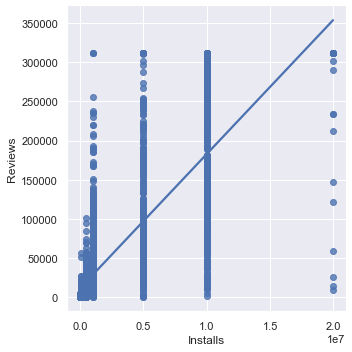

In [40]:
sns.lmplot(data=df, x='Installs', y='Reviews', ci=None);

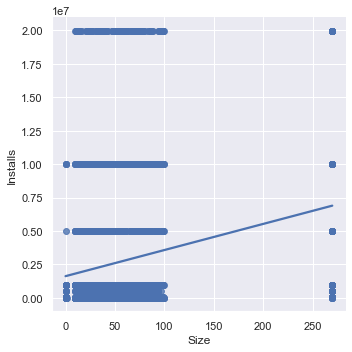

In [41]:
sns.lmplot(data=df, x='Size', y='Installs', ci=None);

<Figure size 720x360 with 0 Axes>

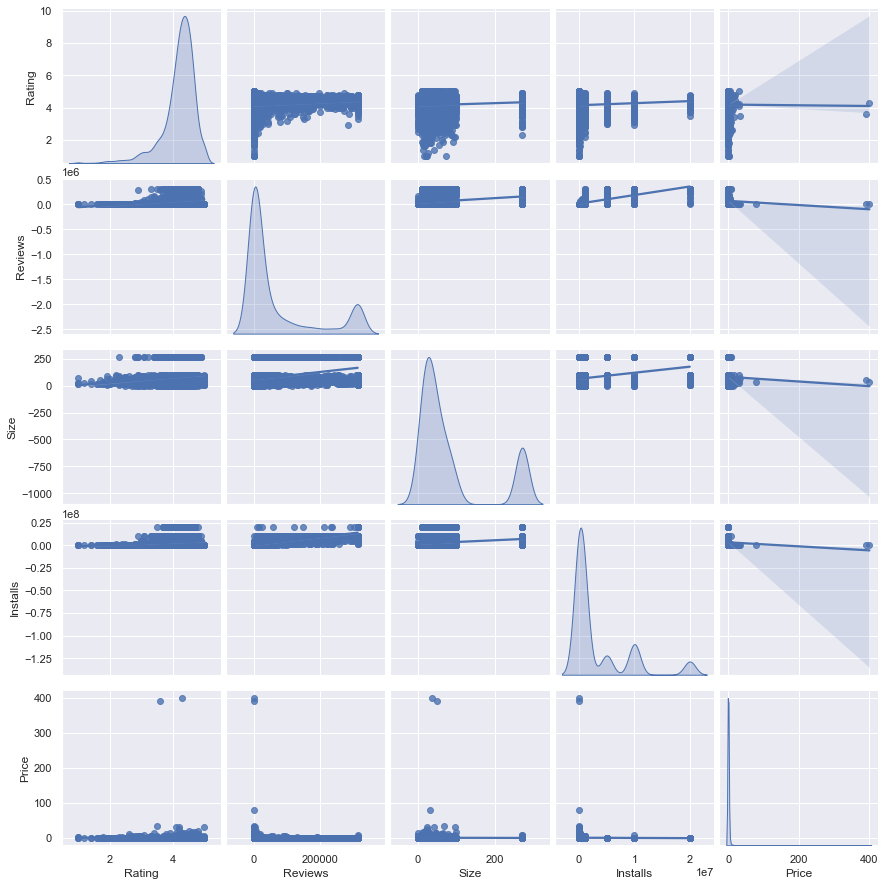

In [42]:
plt.figure(figsize=(10,5))
sns.pairplot(df[['Rating','Reviews','Size','Installs','Price']], kind='reg', diag_kind='kde');

We get the same insights from the scatter plots as we did from the heatmap

#### Relationship between Rating and Category

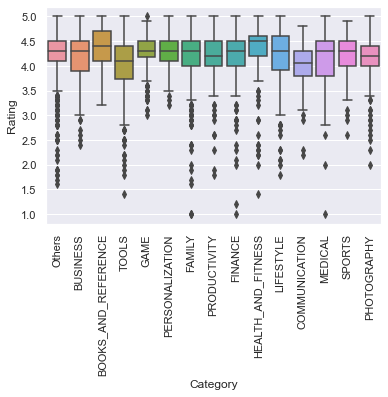

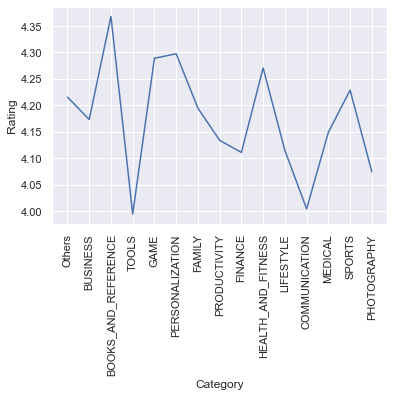

In [43]:
sns.boxplot(data=df, x='Category', y='Rating');
plt.xticks(rotation=90)
plt.show()
sns.lineplot(data=df, x='Category', y='Rating', ci=None);
plt.xticks(rotation=90)
plt.show()

- The category of apps with highest average ratings are Books & References followed by Personalization, Game, Health and Fitness, Sports snd Others, in that order

#### Relationship between Rating and Content Rating

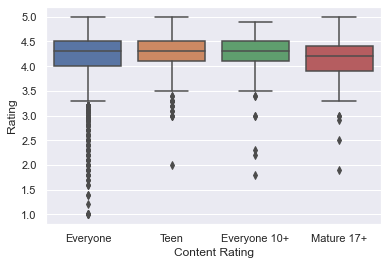

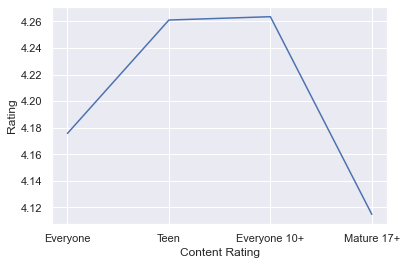

In [44]:
sns.boxplot(data=df, x='Content Rating', y='Rating');
plt.show()
sns.lineplot(data=df, x='Content Rating', y='Rating', ci=None);

Everyone 10+ and Teen apps both have the highest average ratings

#### Relationship between Installs and Category

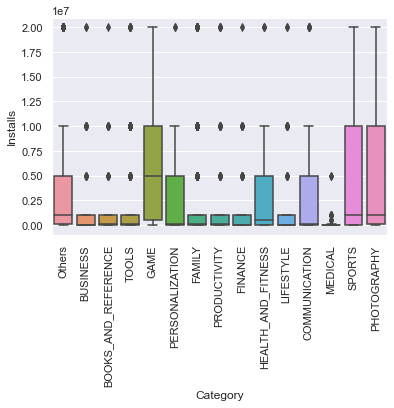

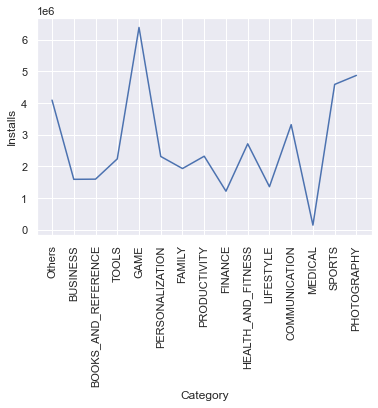

In [45]:
sns.boxplot(data=df, x='Category', y='Installs');
plt.xticks(rotation=90)
plt.show()
sns.lineplot(data=df, x='Category', y='Installs', ci=None);
plt.xticks(rotation=90)
plt.show()

The top 6 average category installs are Game, Photography, Sports, Others, Communication as well as Health and Fitness, in that order

#### Relationship between Installs and Content Rating

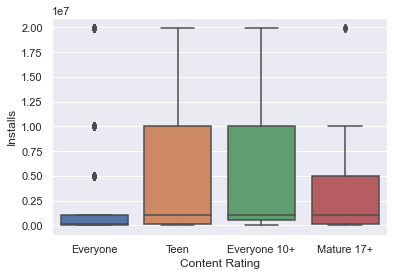

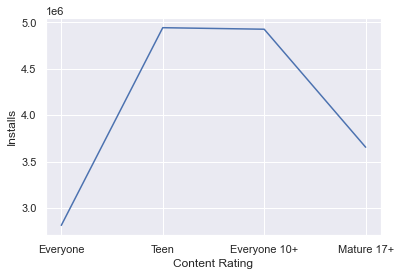

In [49]:
sns.boxplot(data=df, x='Content Rating', y='Installs');
plt.show()
sns.lineplot(data=df, x='Content Rating', y='Installs', ci=None);

Teen apps have the most average installs, followed by Everyone 10+

#### Relationship between Reviews and Category

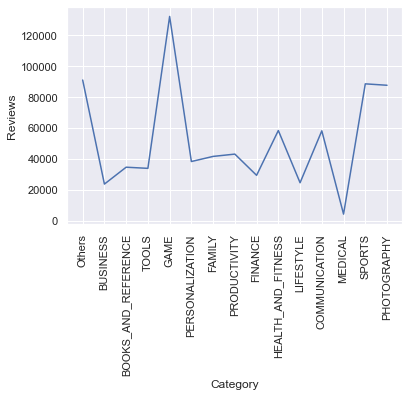

In [52]:
sns.lineplot(data=df, x='Category', y='Reviews', ci=None);
plt.xticks(rotation=90)
plt.show()

In [53]:
df.groupby(['Category'])['Reviews'].mean().reset_index().sort_values('Reviews', ascending=False)

,Category,Reviews
5,GAME,132111.51351
9,Others,90947.33413
13,SPORTS,88474.00000
11,PHOTOGRAPHY,87557.22609
6,HEALTH_AND_FITNESS,58263.03788
2,COMMUNICATION,58059.75532
12,PRODUCTIVITY,42991.66400
3,FAMILY,41494.81127
10,PERSONALIZATION,38186.15044
0,BOOKS_AND_REFERENCE,34505.09524


Highest average category reviews are Game, Sports, and Photography, Others, Health and Fitness as well as Communication, in that order. Almost identical to Installs and this is not surprising, given the strong positve correlation between both features

#### Relationship between Reviews and Content Rating

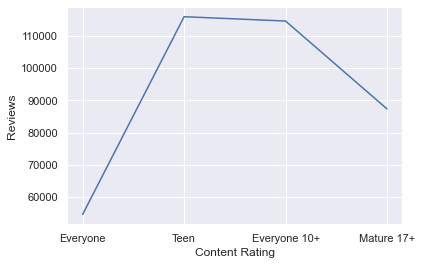

In [54]:
sns.lineplot(data=df, x='Content Rating', y='Reviews', ci=None);

Teen apps and Everyone 10+ have the highest average reviews

## Multivariate Analysis

#### Firstly, having the *Size* column categorised into severals levels might help us get deeper insights into how the size of apps affect customer choices. So let's create a new column with this categorisation

In [5]:
df.describe().T #trying to identify the various bins to be used

,count,mean,std,min,25%,50%,75%,max
Rating,3976.00000,4.18949,0.51979,1.00000,4.00000,4.30000,4.50000,5.00000
Reviews,4029.00000,66964.20675,107418.85154,1.00000,224.00000,7461.00000,78219.00000,312204.00000
Size,4153.00000,82.25441,92.25633,0.01100,22.00000,42.00000,84.00000,270.00000
Installs,4153.00000,3232705.64195,5421343.28486,1.00000,10000.00000,500000.00000,5000000.00000,19970000.00000
Price,4153.00000,0.56534,8.92631,0.00000,0.00000,0.00000,0.00000,399.99000


In [56]:
df['Size_bins'] = pd.cut(df['Size'], bins = [0.011,51,101,271], labels=['Small','Medium','Large'], right=False)

In [57]:
df['Size_bins'].head(6)

0     Large
1     Small
2     Small
3     Small
4     Small
5    Medium
Name: Size_bins, dtype: category
Categories (3, object): ['Small' < 'Medium' < 'Large']

The column creation and categorisation was successful

#### Now let's proceed with our various multivaraite analyses

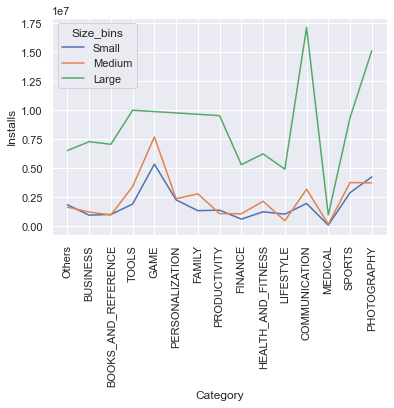

In [58]:
sns.lineplot(data=df, x='Category', y='Installs', hue='Size_bins', ci=None);
plt.xticks(rotation=90)
plt.show()

- **Large**: Top average installs are Communication, Photography, Tools and Sports
- **Medium**: Top average installs are Game, Sports, Photography and Tools
- **Small**: Top avearge installs are Game, Photography and Sports

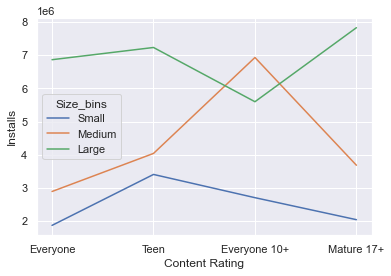

In [59]:
sns.lineplot(data=df, x='Content Rating', y='Installs', hue='Size_bins', ci=None);

- **Large**: Top average installs are Mature 17+ and Teen
- **Medium**: Top average installs are Everyone 10+ and Teen
- **Small**: Top average installs are Teen and Everyone 10+

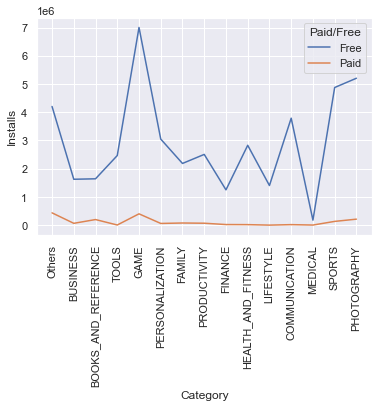

In [60]:
sns.lineplot(data=df, x='Category', y='Installs', hue='Paid/Free', ci=None);
plt.xticks(rotation=90)
plt.show()

In [61]:
df[df['Paid/Free']=='Paid'].groupby(['Category'])['Installs'].mean().reset_index().sort_values('Installs', ascending=False)

,Category,Installs
9,Others,437527.50000
5,GAME,402844.18605
11,PHOTOGRAPHY,214562.50000
0,BOOKS_AND_REFERENCE,200333.33333
13,SPORTS,135012.50000
3,FAMILY,78050.33333
12,PRODUCTIVITY,70370.00000
1,BUSINESS,67000.00000
10,PERSONALIZATION,62676.20690
4,FINANCE,23300.00000


- **Free**: Top average installs are Game, Family, Photography, Sports, Others and Communication
- **Paid**: Top average installs are Others, Game, Photography as well as Books and Reference

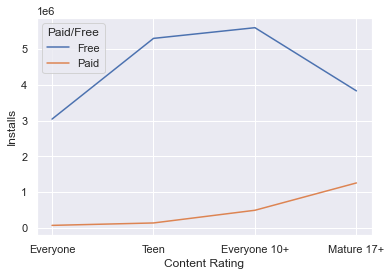

In [62]:
sns.lineplot(data=df, x='Content Rating', y='Installs', hue='Paid/Free', ci=None);

- **Free**: Top average installs are Everyone 10+ and Teen
- **Paid**: Top average installs are Mature 17+ and Everyone 10+

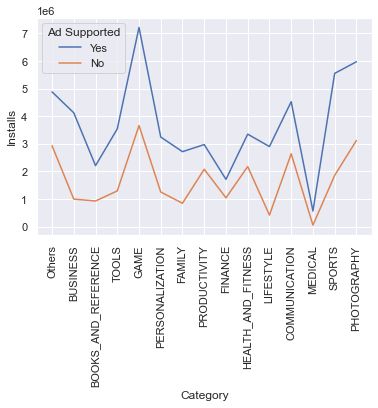

In [63]:
sns.lineplot(data=df, x='Category', y='Installs', hue='Ad Supported', ci=None);
plt.xticks(rotation=90)
plt.show()

- **Ad Supported**: Top average installs are Game, Photography, Sports, Others Communication and Business
- **Not Ad Supported**: Top average installs are Game, Photography, Others and Communication

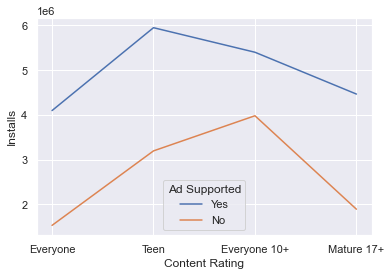

In [64]:
sns.lineplot(data=df, x='Content Rating', y='Installs', hue='Ad Supported', ci=None);

- **Ad Supported**: Top average installs are Teen and Everyone 10+
- **Not Ad Supported**: Top average installs are Everyone 10+ and Teen

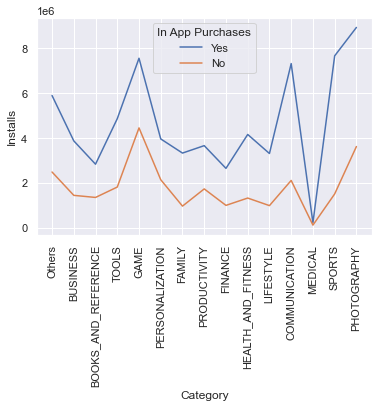

In [65]:
sns.lineplot(data=df, x='Category', y='Installs', hue='In App Purchases', ci=None);
plt.xticks(rotation=90)
plt.show()

- **In App Purchases**: Top average installs are Photography, Sports, Game, Communication and Others
- **No In App Purchases**: Top average installs are Game, Photography and Others

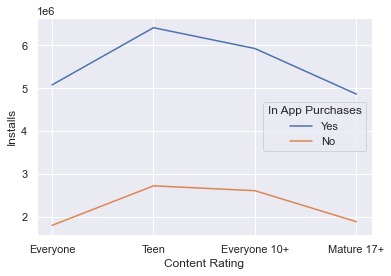

In [66]:
sns.lineplot(data=df, x='Content Rating', y='Installs', hue='In App Purchases', ci=None);

Top average installs for apps with and without in app purchases belong to Teen and Everyone 10+

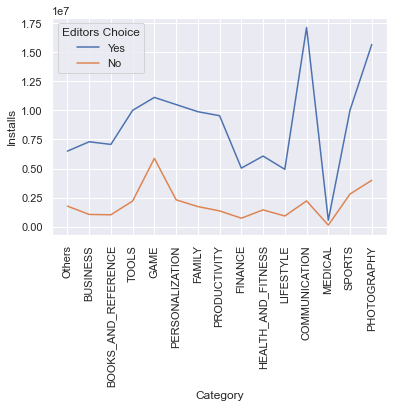

In [67]:
sns.lineplot(data=df, x='Category', y='Installs', hue='Editors Choice', ci=None);
plt.xticks(rotation=90)
plt.show()

- **Editors Choice**: Top average installs are Communication, Photography and Game
- **Not Editors Choice**: Top average installs are Game, Photography and Sports

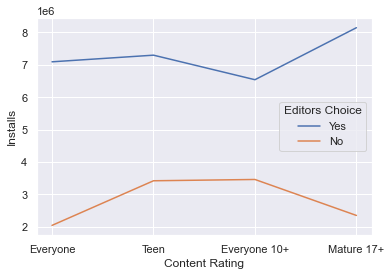

In [68]:
sns.lineplot(data=df, x='Content Rating', y='Installs', hue='Editors Choice', ci=None);

- **Editors Choice**: Top average installs are Mature 17+ and Teen
- **Not Editors Choice**: Top average installs are Everyone 10+ and Tee

In [69]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,3976.00000,4.18949,0.51979,1.00000,4.00000,4.30000,4.50000,5.00000
Reviews,4029.00000,66964.20675,107418.85154,1.00000,224.00000,7461.00000,78219.00000,312204.00000
Size,4153.00000,82.25441,92.25633,0.01100,22.00000,42.00000,84.00000,270.00000
Installs,4153.00000,3232705.64195,5421343.28486,1.00000,10000.00000,500000.00000,5000000.00000,19970000.00000
Price,4153.00000,0.56534,8.92631,0.00000,0.00000,0.00000,0.00000,399.99000


#### Similar to the *Size* column, let's categorise the *Price* column as well into levels to get deeper insights

In [10]:
df.loc[df['Paid/Free']=='Paid']['Price'].min() #trying to identify the bins to use

0.99

In [71]:
df['Price_bins'] = pd.cut(df['Price'], bins=[0.99,21,401], labels=['Low', 'High'], right=False)

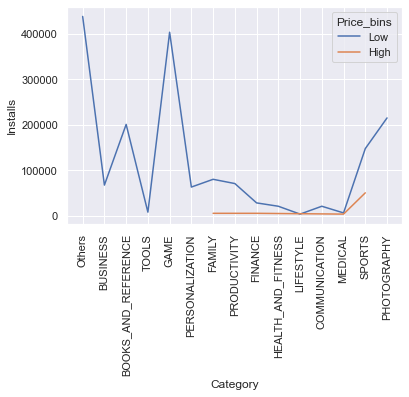

In [72]:
sns.lineplot(data=df, x='Category', y='Installs', hue='Price_bins', ci=None);
plt.xticks(rotation=90)
plt.show()

In [73]:
df[df['Price_bins']=='High'].groupby(['Category'])['Installs'].mean()

Category
FAMILY     5005.00000
FINANCE    5000.00000
MEDICAL    3250.00000
SPORTS    50000.00000
Name: Installs, dtype: float64

- **Low Price**: Top average installs are Others, Game, Photography as well as Books and Reference
- **High Price**: Top average installs is Sports

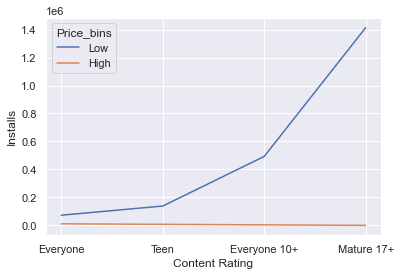

In [74]:
sns.lineplot(data=df, x='Content Rating', y='Installs', hue='Price_bins', ci=None);

In [75]:
df.groupby(['Content Rating','Price_bins'])['Installs'].mean()

Content Rating  Price_bins
Everyone        Low            72696.61157
                High           11142.85714
Everyone 10+    Low           492866.66667
                High                   NaN
Mature 17+      Low          1413262.50000
                High              10.00000
Teen            Low           138248.64865
                High                   NaN
Name: Installs, dtype: float64

- **Low Price**: Top average installs are Mature 17+ and Everyone 10+
- **High Price**: Top average installs is Everyone

## Missing Data Treatment

Creating a dataframe containing the count and percentage of missing values

In [76]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0]/df.shape[0])*100})

,Count,Percentage
Rating,177,4.26198
Reviews,124,2.98579
Price_bins,3828,92.17433


- Rating and Reviews have about 4% and 3% of data missing in them respectively
- We created Price_bins only for a more thorough data exploration. This column will be dropped at the end of the entire analysis and hence, we will not be treating the missing values present in it

Let's see the missing values in Rating in more detail and print out the rows containing the missing values

In [77]:
df.loc[df['Rating'].isnull()==True].tail(60)

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice,Size_bins,Price_bins
2795,Boxing Star,SPORTS,NaN,NaN,270.00000,10000000,Free,0.00000,Teen,Yes,Yes,Yes,Large,NaN
2810,DG Screen Recorder,Others,NaN,12.00000,29.00000,500,Free,0.00000,Everyone,Yes,No,No,Small,NaN
2826,Pill Identifier and Drug list,MEDICAL,NaN,488.00000,17.00000,100000,Free,0.00000,Everyone,Yes,No,No,Small,NaN
2856,防災速報 - 地震、津波、豪雨など、災害情報をいち早くお届け,Others,NaN,26897.00000,270.00000,5000000,Free,0.00000,Everyone,Yes,No,Yes,Large,NaN
2884,Free Resume Builder – CV Maker,BUSINESS,NaN,25.00000,12.00000,5000,Free,0.00000,Everyone,Yes,No,No,Small,NaN
2913,2-Player Co-op Zombie Shoot,GAME,NaN,33.00000,13.00000,1000,Free,0.00000,Teen,Yes,No,No,Small,NaN
2915,MX Player Codec (ARMv7),Others,NaN,312204.00000,63.00000,10000000,Free,0.00000,Everyone,No,No,No,Medium,NaN
2959,Two Dots,Others,NaN,312204.00000,270.00000,10000000,Free,0.00000,Everyone,Yes,Yes,Yes,Large,NaN
2972,C++ Tutorials,Others,NaN,358.00000,19.00000,50000,Free,0.00000,Everyone,Yes,No,No,Small,NaN
2973,Dino T-Rex,GAME,NaN,69115.00000,24.00000,10000000,Free,0.00000,Everyone,Yes,No,No,Small,NaN


- There does not appear to be any pattern in the missingness of data in this column in relation to other columns
- We can proceed to impute the missing values

Since from the frequency distribution of Rating, we know that the column has lots of outliers to the left, we will impute the missing values with the median of the column.
Also apps belonging to the same category and content rating are more likely to be rated similarly, therefore, we will be conducting this imputation based on apps in similar categories and content ratings

In [78]:
df['Rating'] = df['Rating'].fillna(value = df.groupby(['Category','Content Rating'])['Rating'].transform('median'))

Let's see the distribution of the column after imputation

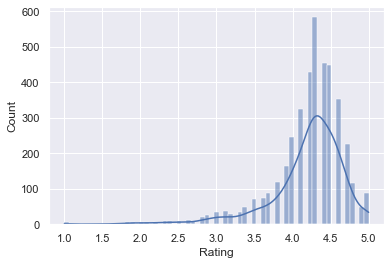

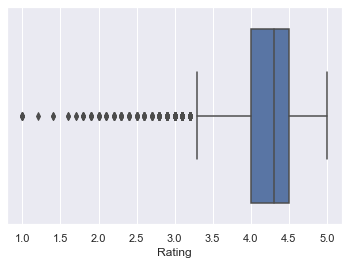

In [79]:
sns.histplot(data=df, x='Rating', kde=True)
plt.show()
sns.boxplot(data=df, x='Rating')
plt.show()

After imputation of the `Rating` column, the distribution is still symmetrical with the original data, which is good

In [80]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0]/df.shape[0])*100})

,Count,Percentage
Reviews,124,2.98579
Price_bins,3828,92.17433


The missing value in the `Rating` column has been treated

Let's now move to Reviews and see the missing values in details

In [81]:
df.loc[df['Reviews'].isnull()==True].tail(60)

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice,Size_bins,Price_bins
2386,Snap Cat Face Camera,PHOTOGRAPHY,4.00000,NaN,49.00000,1000000,Free,0.00000,Everyone,Yes,No,No,Small,NaN
2387,Math Tricks,Others,4.50000,NaN,81.00000,10000000,Free,0.00000,Everyone,Yes,No,No,Medium,NaN
2400,Royal Revolt 2: Tower Defense RTS & Castle Bui...,Others,4.50000,NaN,270.00000,10000000,Free,0.00000,Everyone 10+,Yes,Yes,Yes,Large,NaN
2467,IHG®: Hotel Deals & Rewards,Others,4.30000,NaN,44.00000,1000000,Free,0.00000,Everyone,No,No,No,Small,NaN
2493,Fantastic Chefs: Match 'n Cook,FAMILY,4.30000,NaN,91.00000,500000,Free,0.00000,Everyone,Yes,Yes,No,Medium,NaN
2501,Learn English with ABA English – Study English,Others,4.30000,NaN,270.00000,10000000,Free,0.00000,Everyone,No,Yes,Yes,Large,NaN
2568,RightNow English Conversation,FAMILY,4.00000,NaN,11.00000,1000000,Free,0.00000,Everyone,Yes,Yes,No,Small,NaN
2570,"Hotels.com: Book Hotels, Vacation Rentals and ...",Others,4.50000,NaN,270.00000,10000000,Free,0.00000,Everyone,No,No,Yes,Large,NaN
2664,C B Patel Health Club,HEALTH_AND_FITNESS,5.00000,NaN,14.00000,100,Free,0.00000,Everyone,No,No,No,Small,NaN
2682,Scribd: Audiobooks & ebooks,BOOKS_AND_REFERENCE,4.40000,NaN,270.00000,10000000,Free,0.00000,Teen,No,Yes,Yes,Large,NaN


- In relation to other columns, there does not appear to be any pattern in the missingness of data here as well
- We can proceed to impute the missing values

The distribution of Reviews also shows many outliers to the right, hence, we will follow the same approach used for Rating and impute with the median

In [82]:
df['Reviews'] = df['Reviews'].fillna(value = df.groupby(['Category','Content Rating'])['Reviews'].transform('median'))

Checking the distribution of the column after imputation

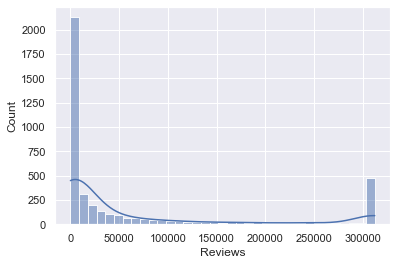

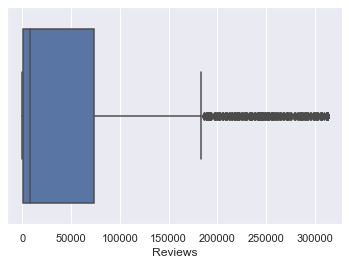

In [83]:
sns.histplot(data=df, x='Reviews', kde=True)
plt.show()
sns.boxplot(data=df, x='Reviews')
plt.show()

Following imputation of the `Reviews` column, the distribution is still symmetrical with the original data, which is good

We will convert Reviews to integer datatype since it should contain discrete data

In [84]:
df['Reviews'] = df['Reviews'].astype('int64')

In [85]:
df['Reviews'].dtypes

dtype('int64')

Datatype conversion was  successful

In [86]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0]/df.shape[0])*100})

,Count,Percentage
Price_bins,3828,92.17433


We will now drop the `Price_bins` column as initially stated

In [87]:
df.drop('Price_bins', axis=1, inplace=True)
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Paid/Free',
       'Price', 'Content Rating', 'Ad Supported', 'In App Purchases',
       'Editors Choice', 'Size_bins'],
      dtype='object')

In [88]:
df.isnull().sum()

App                 0
Category            0
Rating              0
Reviews             0
Size                0
Installs            0
Paid/Free           0
Price               0
Content Rating      0
Ad Supported        0
In App Purchases    0
Editors Choice      0
Size_bins           0
dtype: int64

All missing values have been appropriately treated and the dataset is now missing value-free

Let's drop the `Size_bins` column as this was also created temporarily for deeper dive into the dataset

In [94]:
df.drop('Size_bins', axis=1, inplace=True)
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Paid/Free',
       'Price', 'Content Rating', 'Ad Supported', 'In App Purchases',
       'Editors Choice'],
      dtype='object')

## Actionable Insights and Recommendations

### Insights

We analysed a dataset of almost 4200 applications (apps) in the Google play store and their various relevant information. The data included both free and paid apps classified into 15 different categories and 4 content ratings. The data also included the size of each app, the price (for the those paid), number of installs, number of reviews, and other attributes. The main variable of interest here is the (number of) installs achieved by each app.

We wanted to identify the apps trending in the store, thus, we arrived at the following conclusions:

- All apps belong to one of 15 categories and 4 content rating groups
- 92% of apps are free, while the remaining 8% are paid
- The price range of paid apps is 0.99 to 399.99
- The average app installs is 3232706
- The apps which are trending in the market are those belonging to the:
    - Categories: **Game, Photography and Sports. However, Communication and Others are close followers and are also trending**
    - Content Rating groups: **Teen and Everyone 10+**

### Recommendations

- Zoom Ads should focus its advertisement promotions on applications that belong to the above-mentioned trending *categories* and *content rating groups*, as these will maximise their profits
- Zoom Ads should while upholding the above, also simultaneously take note of the following:
    - Apps that *support ads*, have *in app purchases* and are *editor's choice* are much more preferred to those that are otherwise
    - Apps that are *Free* are far more preferred by users compared to those that are paid. However, if an app is *Paid* and costs *below 20 dollars*, then those belonging to the content rating groups **Everyone 10+, Mature 17+ and Teen** are most preferred. Also, if the app costs *above 20 dollars*, then those belonging to category **Sport** and content rating group **Everyone** trend most
- Apps belonging to the categories Medical, Finance, Lifestyle, Business as well as Books and References trend the least and should be avoided by Zoom Ads
- Finally, there is a high correlation between Reviews and Installations, therefore Zoom Ads should check for those apps which have high number of reviews as those apps are more likely to get installed